### Imports and data 

In [1]:
import pandas as pd
from pathlib import Path
import pandas_datareader.data as web
import datetime
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
!pip install scikit-learn
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [2]:
# ── 1. DICTIONNAIRE DES TICKERS FRED ──
MACRO_TICKERS = {
    "US": "CPIAUCSL",                 # US Consumer Price Index
    "European Union": "CP0000EZ19M086NEST", # Euro Area CPI
    "France": "CP0000FRM086NEST",
    "China": "CHNCPIALLMINMEI",      # China CPI (OCDE)
    "Japan": "CPALCY01JPM661N",
    "India" : "INDCPIALLMINMEI",
    "Africa" : "ZAFCPIALLMINMEI",       # South Africa CPI (Proxy Afrique)
    "Russia" : "RUSCPIALLMINMEI",
    "Middle East": "ISRCPIALLMINMEI", #Isarel CPI (Proxy Moyen-Orient)
    "North America": "CANCPALTT01IXOBSAM",  
    "South America": "BRACPIALLMINMEI", # Brésil CPI (Proxy Amérique du Sud)
    "South East Asia": "IDNCPIALLMINMEI", 
}

In [3]:
# ── 1. Chargement de la base GLOBALE (indicators) ──
dir_global = Path("./indicators")
if dir_global.exists():
    files_global = list(dir_global.glob("*.parquet"))
    df_global = pd.concat([pd.read_parquet(f) for f in files_global], ignore_index=True)
    df_global = df_global.groupby('period').max().reset_index()
    df_global['period'] = pd.to_datetime(df_global['period'])
    df_global = df_global.sort_values('period')
    print(f"✓ Base GLOBALE chargée : {len(df_global)} jours, de {df_global['period'].min().date()} à {df_global['period'].max().date()}")
else:
    df_global = None
    print("⚠ Dossier ./indicators introuvable.")

# ── 2. Chargement de la base RÉGIONALE (indicators_geo) ──
dir_geo = Path("./indicators_geo") # Modifiez si votre dossier s'appelle autrement
if dir_geo.exists():
    files_geo = list(dir_geo.glob("*.parquet"))
    df_geo = pd.concat([pd.read_parquet(f) for f in files_geo], ignore_index=True)
    df_geo = df_geo.groupby(['period', 'region_key']).max().reset_index()
    df_geo['period'] = pd.to_datetime(df_geo['period'])
    df_geo = df_geo.sort_values(['period', 'region_key'])
    print(f"✓ Base RÉGIONALE chargée : {len(df_geo)} lignes, avec les régions {list(df_geo['region_key'].unique())}")
else:
    df_geo = None
    print("⚠ Dossier ./indicators_geo introuvable.")

✓ Base GLOBALE chargée : 4123 jours, de 2015-02-18 à 2026-06-19
✓ Base RÉGIONALE chargée : 53599 lignes, avec les régions ['Africa', 'China', 'European Union', 'France', 'India', 'Japan', 'Lebanon', 'Middle East', 'North America', 'Russia', 'South America', 'South East Asia', 'US']


### Functions 

In [4]:
def load_and_align_multi(df_geo, region_key, type_gdelt, sectors=None, start_date="2014-01-01"):
    """
    Télécharge, aligne et transforme dynamiquement les colonnes GDELT selon leur préfixe.
    Mode Deep Dive : Exclut le secteur parent pour ne garder que ses sous-catégories.
    """
    if region_key not in MACRO_TICKERS:
        raise ValueError(f"Pas de ticker FRED défini pour {region_key}.")
        
    ticker = MACRO_TICKERS[region_key]
    
    # ── 1. TÉLÉCHARGEMENT MACRO ──
    print(f"Téléchargement FRED pour {region_key} ({ticker})...")
    df_macro = web.DataReader(ticker, "fred", start_date)
    df_macro.index.name = 'period'
    macro_col = 'macro_yoy_%'
    df_macro[macro_col] = df_macro[ticker].pct_change(periods=12) * 100
    
    # ── 2. SÉLECTION DYNAMIQUE GDELT ──
    df_g = df_geo[(df_geo['region_key'] == region_key)].set_index('period').copy()
    
    if sectors:
        if len(sectors) == 1:
            # 👉 MODE DEEP DIVE : UNIQUEMENT les sous-catégories (exclusion du parent)
            base_col = f"{type_gdelt}_{sectors[0]}"
            
            # La modification est ici : on exige strictement que la colonne commence par "base_col_" 
            gdelt_cols = [c for c in df_g.columns if c.startswith(f"{base_col}_")]
            
            # Sécurité anti-crash si le secteur n'a aucune sous-catégorie
            if not gdelt_cols:
                print(f"⚠ Aucune sous-catégorie trouvée pour '{sectors[0]}'. Le secteur principal est conservé.")
                gdelt_cols = [base_col]
            else:
                print(f"🔍 Mode Deep Dive sur '{sectors[0]}' : {len(gdelt_cols)} sous-séries (Secteur global exclu).")
        else:
            # 👉 MODE COMPARAISON : Uniquement les agrégats des secteurs listés
            gdelt_cols = [f"{type_gdelt}_{s}" for s in sectors]
            print(f"📊 Mode Comparaison activé sur {len(sectors)} secteurs.")
    else:
        # 👉 MODE EXPLORATION : Toutes les colonnes correspondant au type
        gdelt_cols = [c for c in df_g.columns if c.startswith(f"{type_gdelt}_")]
        print(f"🌍 Mode Exploration Globale : {len(gdelt_cols)} séries détectées.")
        
    if not gdelt_cols:
        raise ValueError(f"Aucune colonne trouvée pour '{type_gdelt}'.")
        
    # Vérification anti-faute de frappe
    missing_cols = [c for c in gdelt_cols if c not in df_g.columns]
    if missing_cols:
        raise ValueError(f"Colonnes GDELT introuvables : {missing_cols}")
    
    # ── 3. TRANSFORMATIONS (Moyenne Mensuelle + Z-Score) ──
    df_g_monthly = df_g[gdelt_cols].resample('MS').mean()
    
    zscore_cols = []
    for col in gdelt_cols:
        rolling_mean = df_g_monthly[col].rolling(window=12).mean()
        rolling_std  = df_g_monthly[col].rolling(window=12).std()
        
        z_col = f"{col}_zscore"
        df_g_monthly[z_col] = (df_g_monthly[col] - rolling_mean) / rolling_std
        zscore_cols.append(z_col)
    
    # ── 4. FUSION ──
    df_merged = pd.merge(df_g_monthly, df_macro, left_index=True, right_index=True, how='inner')
    df_merged = df_merged.dropna()
    
    return df_merged, zscore_cols, macro_col

In [5]:
def plot_macro_vs_multi_gdelt(df_merged, region_key, zscore_cols, macro_col, macro_name="Indicateur Macro"):
    """
    Trace un graphique avec la Macroéconomie à droite et de multiples courbes GDELT à gauche.
    """
    fig = make_subplots(specs=[[{"secondary_y": True}]])
    palette = px.colors.qualitative.Alphabet + px.colors.qualitative.Dark24 # Grande palette

    # Courbe Macro YoY (Axe de droite, mise en évidence)
    fig.add_trace(
        go.Scatter(x=df_merged.index, y=df_merged[macro_col], 
                   name=f"🔴 {macro_name} YoY", 
                   line=dict(color='red', width=4, dash='dot')),
        secondary_y=True,
    )

    # Courbes GDELT Z-Score (Axe de gauche, boucle sur toutes les colonnes)
    for i, col in enumerate(zscore_cols):
        clean_name = col.replace('_zscore', '') # Rendre la légende plus jolie
        fig.add_trace(
            go.Scatter(x=df_merged.index, y=df_merged[col], 
                       name=clean_name, line=dict(color=palette[i % len(palette)], width=2)),
            secondary_y=False,
        )

    fig.update_layout(
        title_text=f"Région : {region_key} | Chocs GDELT (Gauche) vs {macro_name} (Droite)",
        template="plotly_white", hovermode="x unified",
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )
    
    # Ligne zéro de référence
    fig.add_hline(y=0, line_width=1, line_dash="dash", line_color="black", secondary_y=False)
    fig.update_yaxes(title_text="Z-Score (Anomalie Médiatique)", secondary_y=False)
    fig.update_yaxes(title_text="Variation sur 1 an (%)", secondary_y=True)

    fig.show()

In [6]:
def compute_multi_lagged_correlations(df_merged, zscore_cols, macro_col, max_lag=6):
    """
    Génère une matrice de corrélations décalées COMPACTE pour tous les indicateurs GDELT.
    """
    lags = range(-max_lag, max_lag + 1)
    results = {}
    
    for col in zscore_cols:
        col_corrs = []
        for lag in lags:
            # GDELT décalé par rapport à la Macro
            corr = df_merged[col].shift(lag).corr(df_merged[macro_col])
            col_corrs.append(corr)
        clean_name = col.replace('_zscore', '')
        results[clean_name] = col_corrs
        
    # 1. Labels ultra-courts pour gagner de la place en largeur
    index_labels = []
    for lag in lags:
        if lag == 0:
            index_labels.append("T (0)")
        elif lag > 0:
            index_labels.append(f"T+{lag}")
        else:
            index_labels.append(f"T{lag}")
            
    corr_df = pd.DataFrame(results, index=index_labels)
    
    # 2. TRANSPOSITION : Secteurs en lignes, Décalages (Lags) en colonnes
    corr_df = corr_df.T
    
    # 3. STYLISATION AVANCÉE (CSS intégré)
    return (
        corr_df.style
        # axis=None applique l'échelle de couleur sur TOUT le tableau, pas juste colonne par colonne
        .background_gradient(cmap='RdYlBu', vmin=-1, vmax=1, axis=None)
        .format("{:.2f}") # 2 décimales
        .set_properties(**{
            'font-size': '11px',      # Police plus petite
            'padding': '2px 5px',     # Marges réduites dans les cellules
            'text-align': 'center',   # Centrage
            'min-width': '45px'       # Largeur minimale contrainte
        })
    )

In [7]:
def compute_lasso_multi_lags_matrix(df_merged, zscore_cols, macro_col, max_lag=6):
    """
    Exécute un modèle Post-LASSO OLS sur tous les lags simultanément.
    Retourne un tableau récapitulatif coloré selon la significativité des coefficients.
    """
    print(f"🧠 Analyse Post-LASSO OLS globale (Lags de -{max_lag} à +{max_lag})...")
    
    # ── 1. CRÉATION DE LA MATRICE DE TOUS LES LAGS SIMULTANÉS ──
    X_dict = {}
    for col in zscore_cols:
        for lag in range(-max_lag, max_lag + 1):
            X_dict[f"{col}||{lag}"] = df_merged[col].shift(lag)
            
    df_features = pd.DataFrame(X_dict, index=df_merged.index)
    df_features[macro_col] = df_merged[macro_col]
    df_features = df_features.dropna()
    
    X = df_features[list(X_dict.keys())]
    y = df_features[macro_col]
    
    # ── 2. STANDARDISATION ET SÉLECTION VIA LASSO ──
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    lasso = LassoCV(cv=5, random_state=42, max_iter=20000)
    lasso.fit(X_scaled, y)
    
    selected_features = [X.columns[i] for i, coef in enumerate(lasso.coef_) if coef != 0]
    
    # ── 3. ESTIMATION DES P-VALUES VIA POST-LASSO OLS ──
    p_values = {}
    if selected_features:
        X_ols = sm.add_constant(X[selected_features])
        ols_model = sm.OLS(y, X_ols).fit()
        for feat in selected_features:
            p_values[feat] = ols_model.pvalues[feat]
            
    # ── 4. RECONSTRUCTION DU TABLEAU DE SYNTHÈSE ──
    sectors = sorted(list(set([c.split('||')[0].replace('_zscore', '') for c in X.columns])))
    lag_range = list(range(-max_lag, max_lag + 1))
    
    overview_df = pd.DataFrame("", index=sectors, columns=lag_range)
    
    for col_feat in X.columns:
        clean_sector = col_feat.split('||')[0].replace('_zscore', '')
        lag_val = int(col_feat.split('||')[1])
        
        lasso_coef = lasso.coef_[X.columns.get_loc(col_feat)]
        
        if lasso_coef == 0:
            overview_df.loc[clean_sector, lag_val] = "0.00"
        else:
            p_val = p_values.get(col_feat, 1.0)
            if p_val < 0.01:
                stars = "***"
            elif p_val < 0.05:
                stars = "**"
            elif p_val < 0.10:
                stars = "*"
            else:
                stars = " (ns)"
                
            overview_df.loc[clean_sector, lag_val] = f"{lasso_coef:+.2f}{stars}"
            
    columns_mapper = {l: (f"T+{l}" if l > 0 else (f"T{l}" if l < 0 else "T(0)")) for l in lag_range}
    overview_df = overview_df.rename(columns=columns_mapper)
    
    # ── 5. CODE COULEUR DE SIGNIFICATIVITÉ (CSS Dynamique) ──
    def apply_color_code(val):
        if "***" in val:
            # Vert émeraude soutenu - Signal ultra robuste (p < 1%)
            return 'background-color: #2e7d32; color: white; font-weight: bold;'
        elif "**" in val:
            # Vert herbe - Signal robuste (p < 5%)
            return 'background-color: #4caf50; color: white; font-weight: bold;'
        elif "*" in val:
            # Jaune pastel - Signal faible à surveiller (p < 10%)
            return 'background-color: #fff9c4; color: #5d4037;'
        elif "0.00" in val:
            # Gris très clair pour les variables éliminées (Invisible pour l'œil)
            return 'color: #cfd8dc; background-color: #fafafa;'
        else:
            # Variables gardées par le LASSO mais non significatives en OLS
            return 'color: #37474f; background-color: #eceff1;'
            
    return (
        overview_df.style
        .map(apply_color_code) # Applique le code couleur cellule par cellule
        .set_properties(**{
            'font-size': '12px',
            'padding': '6px 10px',
            'text-align': 'center',
            'border': '1px solid #e0e0e0' # Grille fine et propre
        })
    )

In [8]:
def compute_lasso_by_lag_matrix(df_merged, zscore_cols, macro_col, max_lag=6):
    """
    Exécute un modèle LASSO distinct POUR CHAQUE LAG (Horizon par Horizon).
    Les secteurs compétitionnent uniquement au sein d'un même horizon temporel,
    reproduisant les conditions réelles de prévision économique.
    """
    import pandas as pd
    import numpy as np
    from sklearn.linear_model import LassoCV
    from sklearn.preprocessing import StandardScaler
    import statsmodels.api as sm

    lag_range = list(range(-max_lag, max_lag + 1))
    # Extraction propre des noms de secteurs
    sectors = sorted(list(set([c.replace('_zscore', '') for c in zscore_cols])))
    
    # DataFrame final pour stocker la synthèse
    overview_df = pd.DataFrame("", index=sectors, columns=lag_range)

    # ── LA DISSOCIATION : On boucle SUR CHAQUE LAG INDÉPENDAMMENT ──
    for lag in lag_range:
        # 1. Création du mini-dataset dédié à ce lag spécifique
        X_dict = {}
        for col in zscore_cols:
            X_dict[col] = df_merged[col].shift(lag)
            
        df_lag = pd.DataFrame(X_dict, index=df_merged.index)
        df_lag[macro_col] = df_merged[macro_col]
        df_lag = df_lag.dropna()
        
        # Sécurité si le décalage vide trop la base
        if len(df_lag) < 15:
            continue
            
        X = df_lag[zscore_cols]
        y = df_lag[macro_col]
        
        # 2. Standardisation et LASSO local
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # Le modèle ne gère plus que p variables (et non p x lags), il est beaucoup plus stable
        lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
        lasso.fit(X_scaled, y)
        
        # 3. Post-LASSO OLS local pour la significativité
        selected_features = [X.columns[i] for i, coef in enumerate(lasso.coef_) if coef != 0]
        
        p_values = {f: 1.0 for f in zscore_cols}
        if selected_features:
            X_ols = sm.add_constant(X[selected_features])
            ols_model = sm.OLS(y, X_ols).fit()
            for feat in selected_features:
                p_values[feat] = ols_model.pvalues[feat]
        
        # 4. Remplissage de la colonne correspondante dans notre tableau
        for i, col in enumerate(zscore_cols):
            clean_sector = col.replace('_zscore', '')
            coef = lasso.coef_[i]
            
            if coef == 0:
                overview_df.loc[clean_sector, lag] = "0.00"
            else:
                p_val = p_values.get(col, 1.0)
                if p_val < 0.01: stars = "***"
                elif p_val < 0.05: stars = "**"
                elif p_val < 0.10: stars = "*"
                else: stars = " (ns)"
                
                overview_df.loc[clean_sector, lag] = f"{coef:+.2f}{stars}"

    # Formatage cosmétique des en-têtes de colonnes
    columns_mapper = {l: (f"T+{l}" if l > 0 else (f"T{l}" if l < 0 else "T(0)")) for l in lag_range}
    overview_df = overview_df.rename(columns=columns_mapper)
    
    # Même logique de code couleur automatique
    def apply_color_code(val):
        if "***" in val: return 'background-color: #2e7d32; color: white; font-weight: bold;'
        elif "**" in val: return 'background-color: #4caf50; color: white; font-weight: bold;'
        elif "*" in val: return 'background-color: #fff9c4; color: #5d4037;'
        elif "0.00" in val: return 'color: #cfd8dc; background-color: #fafafa;'
        else: return 'color: #37474f; background-color: #eceff1;'
            
    return overview_df.style.map(apply_color_code).set_properties(**{
        'font-size': '12px',
        'padding': '6px 10px',
        'text-align': 'center',
        'border': '1px solid #e0e0e0'
    })

In [9]:
def compute_lasso_by_lag_with_ar_matrix(df_merged, zscore_cols, macro_col, max_lag=6):
    """
    Exécute un modèle LASSO distinct pour chaque lag (Horizon par Horizon)
    en ajoutant l'inflation passée (terme autorégressif) comme variable de contrôle 
    pour les horizons prédictifs (lags > 0).
    """
    import pandas as pd
    import numpy as np
    from sklearn.linear_model import LassoCV
    from sklearn.preprocessing import StandardScaler
    import statsmodels.api as sm

    lag_range = list(range(-max_lag, max_lag + 1))
    sectors = sorted(list(set([c.replace('_zscore', '') for c in zscore_cols])))
    
    # On ajoute une ligne spéciale dans notre tableau pour voir le poids de l'inflation passée
    row_labels = sectors + ["_PAST_MACRO_INERTIA_"]
    overview_df = pd.DataFrame("", index=row_labels, columns=lag_range)

    for lag in lag_range:
        # 1. Construction du dataset pour ce lag spécifique
        X_dict = {}
        for col in zscore_cols:
            X_dict[col] = df_merged[col].shift(lag)
            
        # CRUCIAL : Si on essaie de prédire le FUTUR (lag > 0), 
        # on injecte l'inflation du passé (décalée du même lag) comme variable explicative
        if lag > 0:
            X_dict["_PAST_MACRO_INERTIA_"] = df_merged[macro_col].shift(lag)
            
        df_lag = pd.DataFrame(X_dict, index=df_merged.index)
        df_lag[macro_col] = df_merged[macro_col]
        df_lag = df_lag.dropna()
        
        if len(df_lag) < 15:
            continue
            
        current_features = list(X_dict.keys())
        X = df_lag[current_features]
        y = df_lag[macro_col]
        
        # 2. LASSO
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
        lasso.fit(X_scaled, y)
        
        # 3. Post-LASSO OLS pour la significativité
        selected_features = [X.columns[i] for i, coef in enumerate(lasso.coef_) if coef != 0]
        
        p_values = {f: 1.0 for f in current_features}
        if selected_features:
            X_ols = sm.add_constant(X[selected_features])
            ols_model = sm.OLS(y, X_ols).fit()
            for feat in selected_features:
                p_values[feat] = ols_model.pvalues[feat]
        
        # 4. Remplissage du tableau
        for feat in current_features:
            coef = lasso.coef_[X.columns.get_loc(feat)]
            p_val = p_values.get(feat, 1.0)
            
            if p_val < 0.01: stars = "***"
            elif p_val < 0.05: stars = "**"
            elif p_val < 0.10: stars = "*"
            else: stars = " (ns)"
            
            # Détermination de la ligne de destination
            dest_row = "_PAST_MACRO_INERTIA_" if feat == "_PAST_MACRO_INERTIA_" else feat.replace('_zscore', '')
            
            if coef == 0:
                overview_df.loc[dest_row, lag] = "0.00"
            else:
                overview_df.loc[dest_row, lag] = f"{coef:+.2f}{stars}"

    # Nettoyage des cellules vides pour les lignes/colonnes non concernées
    overview_df.loc["_PAST_MACRO_INERTIA_", [l for l in lag_range if l <= 0]] = "N/A"
    
    # Formatage cosmétique
    columns_mapper = {l: (f"T+{l}" if l > 0 else (f"T{l}" if l < 0 else "T(0)")) for l in lag_range}
    overview_df = overview_df.rename(columns=columns_mapper)
    
    def apply_color_code(val):
        if val == "N/A": return 'color: #b0bec5; background-color: #cfd8dc; font-style: italic;'
        elif "***" in val: return 'background-color: #2e7d32; color: white; font-weight: bold;'
        elif "**" in val: return 'background-color: #4caf50; color: white; font-weight: bold;'
        elif "*" in val: return 'background-color: #fff9c4; color: #5d4037;'
        elif "0.00" in val: return 'color: #cfd8dc; background-color: #fafafa;'
        else: return 'color: #37474f; background-color: #eceff1;'
            
    return overview_df.style.map(apply_color_code).set_properties(**{
        'font-size': '12px', 'padding': '6px 10px', 'text-align': 'center', 'border': '1px solid #e0e0e0'
    })

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

def plot_out_of_sample_forecast(df_merged, zscore_cols, macro_col, lag_months=2, test_ratio=0.25):
    """
    Simule une prévision réelle en coupant les données (Train = Passé, Test = Futur).
    Compare un modèle 'Inertie Seule' vs 'Inertie + GDELT'.
    """
    print(f"🔮 Test Out-of-Sample à T+{lag_months} mois")
    
    # 1. Préparation des données décalées
    df_model = pd.DataFrame(index=df_merged.index)
    df_model['Target_Macro'] = df_merged[macro_col]
    df_model['Past_Macro'] = df_merged[macro_col].shift(lag_months)
    
    for col in zscore_cols:
        df_model[col] = df_merged[col].shift(lag_months)
        
    df_model = df_model.dropna()
    
    # 2. Split temporel strict (Pas de mélange aléatoire !)
    split_idx = int(len(df_model) * (1 - test_ratio))
    train_data = df_model.iloc[:split_idx]
    test_data = df_model.iloc[split_idx:]
    split_date = test_data.index[0].strftime('%Y-%m')
    print(f"Entraînement jusqu'à {split_date} | Test sur les données suivantes.")

    # Variables
    X_train_naive = train_data[['Past_Macro']]
    X_test_naive = test_data[['Past_Macro']]
    
    X_train_full = train_data[['Past_Macro'] + zscore_cols]
    X_test_full = test_data[['Past_Macro'] + zscore_cols]
    
    y_train = train_data['Target_Macro']
    y_test = test_data['Target_Macro']
    
    # 3. Entraînement Modèle Naïf (Régression simple sur le passé)
    model_naive = LinearRegression()
    model_naive.fit(X_train_naive, y_train)
    preds_naive = model_naive.predict(X_test_naive)
    
    # 4. Entraînement Modèle Complet (LASSO avec StandardScaler)
    scaler = StandardScaler()
    X_train_full_scaled = scaler.fit_transform(X_train_full)
    X_test_full_scaled = scaler.transform(X_test_full)
    
    model_full = LassoCV(cv=5, random_state=42)
    model_full.fit(X_train_full_scaled, y_train)
    preds_full = model_full.predict(X_test_full_scaled)
    
    # 5. Calcul des erreurs (RMSE : Plus c'est bas, mieux c'est)
    rmse_naive = np.sqrt(mean_squared_error(y_test, preds_naive))
    rmse_full = np.sqrt(mean_squared_error(y_test, preds_full))
    
    print(f"📉 Erreur Modèle Naïf   : {rmse_naive:.3f}")
    print(f"📉 Erreur Modèle Complet: {rmse_full:.3f}")
    if rmse_full < rmse_naive:
        print("✅ VICTOIRE : GDELT améliore concrètement la prévision !")
    else:
        print("❌ ECHEC : GDELT n'apporte pas d'information supérieure à l'inertie.")

    # 6. Graphique
    plt.figure(figsize=(12, 6))
    plt.plot(train_data.index, y_train, color='black', alpha=0.3, label='Réalité (In-Sample)')
    plt.plot(test_data.index, y_test, color='black', linewidth=2, label='Réalité (Out-of-Sample)')
    plt.plot(test_data.index, preds_naive, color='red', linestyle='--', label='Prévision Naïve (Sans GDELT)')
    plt.plot(test_data.index, preds_full, color='blue', linewidth=2, label='Prévision Modèle (Avec GDELT)')
    
    plt.axvline(train_data.index[-1], color='gray', linestyle=':', linewidth=2)
    plt.title(f"Test de Prévision sur données invisibles (Horizon {lag_months} mois)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [11]:
def plot_rolling_coefficients(df_merged, zscore_cols, macro_col, target_sector, lag_months=1, window_size=48):
    """
    Calcule et trace l'évolution du coefficient d'un secteur spécifique au fil du temps 
    (Fenêtre glissante). Idéal pour détecter les changements de régime économique.
    """
    print(f"⏳ Analyse glissante sur fenêtres de {window_size} mois (Lag: {lag_months})")
    
    # ── SÉCURITÉ : Rajoute '_zscore' si l'utilisateur l'a oublié ──
    if not target_sector.endswith('_zscore'):
        target_sector += '_zscore'
        
    if target_sector not in zscore_cols:
        raise ValueError(f"Le secteur '{target_sector}' est introuvable. Colonnes disponibles : {zscore_cols}")
        
    df_model = pd.DataFrame(index=df_merged.index)
    df_model['Target_Macro'] = df_merged[macro_col]
    df_model['Past_Macro'] = df_merged[macro_col].shift(lag_months)
    
    for col in zscore_cols:
        df_model[col] = df_merged[col].shift(lag_months)
        
    df_model = df_model.dropna()
    
    dates = []
    coefs = []
    
    # Boucle Glissante (Rolling Window)
    for i in range(len(df_model) - window_size):
        window_data = df_model.iloc[i : i + window_size]
        X = window_data[['Past_Macro'] + zscore_cols]
        y = window_data['Target_Macro']
        
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        from sklearn.linear_model import Ridge
        model = Ridge(alpha=1.0)
        model.fit(X_scaled, y)
        
        target_idx = zscore_cols.index(target_sector) + 1
        coefs.append(model.coef_[target_idx])
        dates.append(window_data.index[-1]) 
        
    # Graphique
    plt.figure(figsize=(10, 5))
    plt.plot(dates, coefs, color='darkorange', linewidth=2.5)
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    
    plt.fill_between(dates, 0, coefs, where=(np.array(coefs) > 0), color='green', alpha=0.2)
    plt.fill_between(dates, 0, coefs, where=(np.array(coefs) < 0), color='red', alpha=0.2)
    
    clean_name = target_sector.replace('_zscore', '')
    plt.title(f"Évolution de l'influence de '{clean_name}' sur l'inflation au fil du temps")
    plt.ylabel("Poids (Coefficient)")
    plt.grid(alpha=0.3)
    plt.show()

In [12]:
from statsmodels.tsa.api import VAR
import matplotlib.pyplot as plt

def plot_var_irf(df_merged, gdelt_col, macro_col, max_lag_var=3, steps_ahead=12):
    """
    Modélise un choc sur la variable GDELT et trace la réponse de l'inflation (IRF).
    """
    # ── SÉCURITÉ : Rajoute '_zscore' ──
    if not gdelt_col.endswith('_zscore'):
        gdelt_col += '_zscore'
        
    print(f"💥 Simulation de Choc (Modèle VAR) sur : {gdelt_col.replace('_zscore', '')}")
    
    # 1. Isoler les deux variables pour le modèle VAR
    df_var = df_merged[[gdelt_col, macro_col]].dropna()
    
    # 2. Entraînement du modèle VAR
    model = VAR(df_var)
    results = model.fit(maxlags=max_lag_var, ic='aic')
    
    # 3. Calcul de la Réponse Impulsionnelle (IRF)
    irf = results.irf(steps_ahead)
    
    # ── CORRECTION : Extraction officielle des bornes de confiance dans statsmodels ──
    lower_bound_matrix, upper_bound_matrix = irf.err_band_sz1(orth=True, signif=0.05)
    
    # 4. Graphique
    plt.figure(figsize=(8, 5))
    
    # L'index 1 est la macro, l'index 0 est gdelt. Donc choc sur 0 -> effet sur 1.
    effect_on_macro = irf.orth_irfs[:, 1, 0] 
    lower_bound = lower_bound_matrix[:, 1, 0]
    upper_bound = upper_bound_matrix[:, 1, 0]
    
    plt.plot(range(steps_ahead + 1), effect_on_macro, color='blue', linewidth=2, label="Impact sur l'Inflation")
    
    # Intervalle de confiance à 95%
    plt.fill_between(range(steps_ahead + 1), lower_bound, upper_bound, color='blue', alpha=0.15, label="Intervalle de Confiance (95%)")
    plt.axhline(0, color='black', linestyle='--')
    
    clean_name = gdelt_col.replace('_zscore', '')
    plt.title(f"Réponse de l'inflation suite à un choc médiatique sur '{clean_name}'")
    plt.xlabel("Mois après le choc")
    plt.ylabel("Impact (%)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

### Viz



In [13]:
region = "European Union"
type_gdelt_indicator = "att_weight"
sectors = ["finance", "energy", "agriculture", "tech", "industry", "commodities", "real_estate", "transport"]  # Liste des secteurs à comparer

df_align, z_cols, m_col = load_and_align_multi(
    df_geo=df_geo, 
    region_key=region, 
    type_gdelt=type_gdelt_indicator, 
    sectors=sectors 
)

# Le graphique affichera l'énergie globale + le pétrole, le nucléaire, etc.
plot_macro_vs_multi_gdelt(df_align, region, z_cols, m_col, macro_name="Inflation")

# La matrice détaillera les corrélations de chaque sous-catégorie
display(compute_multi_lagged_correlations(df_align, z_cols, m_col, max_lag=6))

Téléchargement FRED pour European Union (CP0000EZ19M086NEST)...
📊 Mode Comparaison activé sur 8 secteurs.


,T-6,T-5,T-4,T-3,T-2,T-1,T (0),T+1,T+2,T+3,T+4,T+5,T+6
att_weight_finance,0.08,0.15,0.21,0.28,0.33,0.39,0.43,0.48,0.51,0.55,0.59,0.61,0.61
att_weight_energy,-0.11,-0.07,-0.03,-0.00,0.04,0.10,0.16,0.22,0.26,0.28,0.29,0.31,0.33
att_weight_agriculture,0.15,0.19,0.21,0.22,0.27,0.32,0.37,0.40,0.44,0.48,0.51,0.53,0.54
att_weight_tech,0.18,0.23,0.26,0.27,0.30,0.32,0.33,0.36,0.36,0.35,0.34,0.34,0.32
att_weight_industry,0.30,0.30,0.29,0.27,0.27,0.25,0.24,0.21,0.17,0.12,0.06,0.03,-0.02
att_weight_commodities,-0.02,0.01,0.03,0.07,0.09,0.13,0.16,0.19,0.22,0.24,0.27,0.29,0.30
att_weight_real_estate,0.37,0.35,0.32,0.29,0.27,0.25,0.24,0.22,0.20,0.18,0.17,0.15,0.13
att_weight_transport,0.19,0.21,0.20,0.18,0.16,0.17,0.18,0.18,0.17,0.17,0.16,0.15,0.12


In [108]:
region = "US"
type_gdelt_indicator = "att_weight"
sectors = ["finance", "energy", "agriculture", "tech", "industry", "commodities", "real_estate", "transport"]  # Liste des secteurs à comparer

df_align, z_cols, m_col = load_and_align_multi(
    df_geo=df_geo, 
    region_key=region, 
    type_gdelt=type_gdelt_indicator, 
    sectors=sectors 
)

# Le graphique affichera l'énergie globale + le pétrole, le nucléaire, etc.
plot_macro_vs_multi_gdelt(df_align, region, z_cols, m_col, macro_name="Inflation")

# La matrice détaillera les corrélations de chaque sous-catégorie
display(compute_multi_lagged_correlations(df_align, z_cols, m_col, max_lag=6))

Téléchargement FRED pour US (CPIAUCSL)...
📊 Mode Comparaison activé sur 8 secteurs.


,T-6,T-5,T-4,T-3,T-2,T-1,T (0),T+1,T+2,T+3,T+4,T+5,T+6
att_weight_finance,0.35,0.39,0.43,0.47,0.49,0.52,0.51,0.51,0.53,0.55,0.56,0.55,0.50
att_weight_energy,0.06,0.05,0.07,0.08,0.09,0.09,0.09,0.11,0.14,0.15,0.16,0.13,0.09
att_weight_agriculture,0.23,0.26,0.29,0.32,0.35,0.39,0.42,0.44,0.44,0.45,0.45,0.42,0.39
att_weight_tech,0.18,0.16,0.12,0.11,0.12,0.16,0.18,0.19,0.16,0.11,0.09,0.07,0.05
att_weight_industry,0.31,0.31,0.29,0.27,0.27,0.23,0.20,0.19,0.16,0.12,0.09,0.06,0.04
att_weight_commodities,0.07,0.10,0.13,0.16,0.19,0.24,0.28,0.31,0.35,0.37,0.38,0.38,0.37
att_weight_real_estate,0.32,0.32,0.34,0.37,0.40,0.44,0.46,0.49,0.52,0.54,0.56,0.57,0.58
att_weight_transport,0.10,0.12,0.15,0.17,0.19,0.23,0.25,0.28,0.28,0.25,0.24,0.24,0.23


### Models 

In [ ]:
region = "US"
type_gdelt_indicator = "att_weight"
sectors = ["real_estate"]  # Liste des secteurs à comparer

df_align, z_cols, m_col = load_and_align_multi(
    df_geo=df_geo, 
    region_key=region, 
    type_gdelt=type_gdelt_indicator, 
    sectors=sectors 
)

Téléchargement FRED pour US (CPIAUCSL)...
🔍 Mode Deep Dive sur 'real_estate' : 5 sous-séries (Secteur global exclu).
🧠 Analyse Post-LASSO OLS globale (Lags de -6 à +6)...


,T-6,T-5,T-4,T-3,T-2,T-1,T(0),T+1,T+2,T+3,T+4,T+5,T+6
att_weight_real_estate_construction,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.10*,-0.01 (ns),0.00
att_weight_real_estate_financing,+0.25*,+0.13 (ns),+0.19 (ns),+0.30**,+0.31**,+0.28**,+0.21**,+0.17 (ns),+0.25***,+0.27**,+0.22 (ns),+0.25 (ns),+0.09 (ns)
att_weight_real_estate_market,-0.03 (ns),-0.09 (ns),-0.12 (ns),-0.15 (ns),-0.13 (ns),-0.17 (ns),-0.08 (ns),0.00,0.00,0.00,0.00,0.00,+0.12 (ns)
att_weight_real_estate_regulation,-0.09 (ns),0.00,0.00,0.00,-0.03 (ns),-0.06 (ns),-0.00 (ns),0.00,0.00,0.00,+0.08 (ns),+0.06 (ns),+0.11 (ns)
att_weight_real_estate_urbanism,+0.11**,+0.06 (ns),0.00,+0.00 (ns),+0.13**,+0.16 (ns),+0.05 (ns),+0.08 (ns),+0.12 (ns),+0.08 (ns),+0.05 (ns),+0.08 (ns),+0.28 (ns)


In [102]:
compute_lasso_by_lag_with_ar_matrix(df_align, z_cols, m_col)

,T-6,T-5,T-4,T-3,T-2,T-1,T(0),T+1,T+2,T+3,T+4,T+5,T+6
att_weight_real_estate_construction,+0.08 (ns),+0.08 (ns),+0.10 (ns),+0.08 (ns),+0.12 (ns),+0.15 (ns),+0.22 (ns),0.00,0.00,0.00,0.00,0.00,0.00
att_weight_real_estate_financing,+0.29**,+0.34**,+0.48***,+0.58***,+0.64***,+0.65***,+0.61***,0.00,0.00,0.00,+0.02 (ns),0.00,0.00
att_weight_real_estate_market,0.00,0.00,0.00,0.00,0.00,0.00,+0.00 (ns),+0.03**,+0.06**,+0.06**,+0.13**,+0.12***,+0.12***
att_weight_real_estate_regulation,0.00,0.00,0.00,0.00,0.00,+0.01 (ns),+0.07 (ns),+0.03**,+0.07**,+0.10***,+0.10**,+0.13***,+0.13***
att_weight_real_estate_urbanism,+0.47***,+0.45**,+0.46**,+0.48***,+0.53***,+0.57***,+0.60***,0.00,0.00,0.00,0.00,0.00,0.00
_PAST_MACRO_INERTIA_,N/A,N/A,N/A,N/A,N/A,N/A,N/A,+1.93***,+1.78***,+1.63***,+1.48***,+1.31***,+1.14***


🔮 Test Out-of-Sample à T+2 mois
Entraînement jusqu'à 2023-10 | Test sur les données suivantes.
📉 Erreur Modèle Naïf   : 0.449
📉 Erreur Modèle Complet: 0.500
❌ ECHEC : GDELT n'apporte pas d'information supérieure à l'inertie.


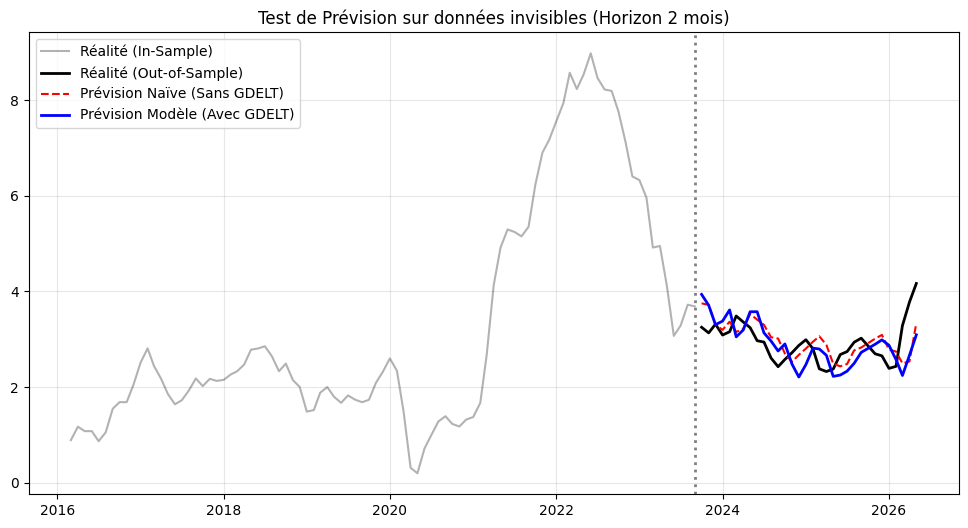

In [106]:
plot_out_of_sample_forecast(df_align, z_cols, m_col, lag_months=2, test_ratio=0.25)

⏳ Analyse glissante sur fenêtres de 48 mois (Lag: 1)


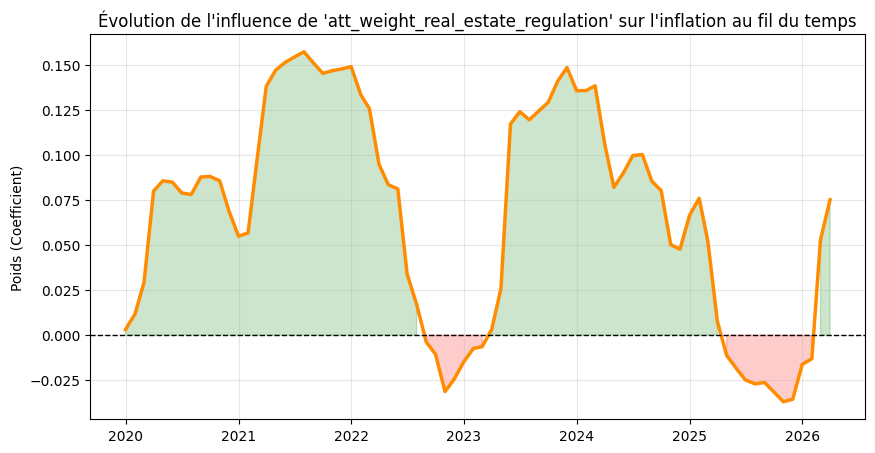

In [107]:
# 1. Évolution de l'influence du secteur "Transport" au fil du temps
plot_rolling_coefficients(
    df_merged=df_align, 
    zscore_cols=z_cols, 
    macro_col=m_col, 
    target_sector="att_weight_real_estate_regulation", # Remplacez par le secteur de votre choix
    lag_months=1,      # On étudie sa capacité à prédire l'inflation à +1 mois
    window_size=48     # Taille de la fenêtre : 48 mois (4 ans d'apprentissage glissant)
)

💥 Simulation de Choc (Modèle VAR) sur : att_weight_real_estate_regulation


/home/clucas/venvs/gdelt/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/clucas/venvs/gdelt/lib/python3.12/site-packages/statsmodels/tsa/vector_ar/irf.py:528: ComplexWarning: Casting complex values to real discards the imaginary part
  W[i,j,:,:], eigva[i,j,:,0], k[i,j] = util.eigval_decomp(cov_hold[i,j,:,:])


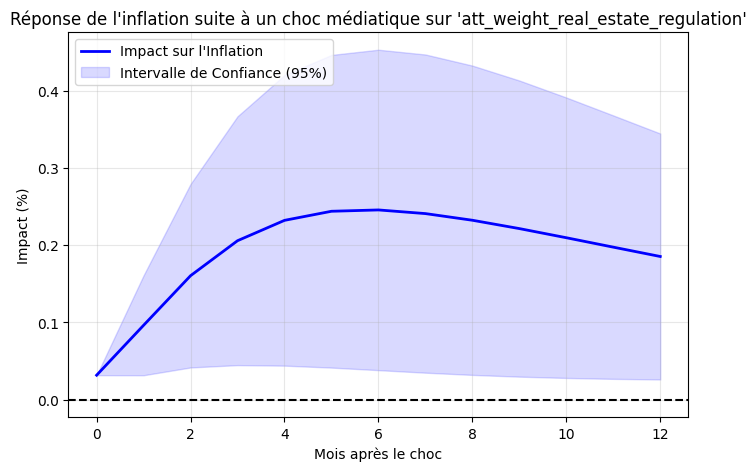

In [108]:
# 2. Impact d'un choc médiatique sur l'inflation (Courbe de réponse)
plot_var_irf(
    df_merged=df_align, 
    gdelt_col="att_weight_real_estate_regulation", # Le secteur qui va subir le choc de +1 écart-type
    macro_col=m_col, 
    max_lag_var=12,     # Le modèle utilise 12 mois d'historique pour modéliser la relation
    steps_ahead=12     # On trace la propagation de l'onde de choc sur les 12 prochains mois
)

### Test

In [120]:
def generate_regional_report(df_geo, region, type_gdelt, sectors, oos_test_ratio=0.25):
    """
    Pipeline automatisé : Exécute de bout en bout l'analyse macro vs GDELT pour une région donnée.
    Sélectionne dynamiquement le meilleur indicateur avancé (T+1 à T+6) et l'horizon optimal.
    """
    print(f"===================================================================")
    print(f"🌍 RAPPORT SYSTÉMATIQUE : {region.upper()} | INDICATEUR : {type_gdelt.upper()}")
    print(f"===================================================================\n")
    
    # 1. Alignement des données
    try:
        df_align, z_cols, m_col = load_and_align_multi(
            df_geo=df_geo, region_key=region, type_gdelt=type_gdelt, sectors=sectors
        )
    except Exception as e:
        print(f"❌ Erreur lors de l'alignement pour {region}: {e}")
        return

    # 2. Détection du meilleur Prédicteur Avancé (Strictement sur T+1 à T+6)
    # Élimine le biais de simultanéité (T=0) et de retard (T<0)
    best_sector = None
    best_score = 0
    best_lag = 1
    
    for col in z_cols:
        for lag in range(1, 7): # Boucle uniquement sur le futur
            corr = df_align[col].shift(lag).corr(df_align[m_col])
            
            if pd.notna(corr) and abs(corr) > best_score:
                best_score = abs(corr)
                best_sector = col
                best_lag = lag

    if not best_sector:
        print("⚠ Impossible de trouver un prédicteur valide avec les données actuelles.")
        return

    clean_sector_name = best_sector.replace('_zscore', '')
    print(f"🎯 PRÉDICTEUR OPTIMAL DÉTECTÉ : {clean_sector_name.upper()}")
    print(f"   => Pic de signal prédictif à : T+{best_lag} mois (Corrélation: {best_score:.2f})")

    # 3. Affichage de la Matrice Econométrique (Le Diagnostic)
    print("\n📌 1. DIAGNOSTIC ÉCONOMÉTRIQUE (Post-LASSO OLS avec Inertie)")
    lasso_matrix = compute_lasso_by_lag_with_ar_matrix(df_align, z_cols, m_col, max_lag=6)
    display(lasso_matrix)
    
    # 4. Le Test Out-of-Sample (La Preuve)
    # ⚡ Le test de prévision utilise désormais le meilleur lag trouvé automatiquement !
    print(f"\n📌 2. TEST DE PRÉVISION EN CONDITIONS RÉELLES (Horizon cible : +{best_lag} mois)")
    plot_out_of_sample_forecast(df_align, z_cols, m_col, lag_months=best_lag, test_ratio=oos_test_ratio)
    
    # 5. La Courbe de Choc (L'Impact)
    print(f"\n📌 3. DYNAMIQUE DE CHOC (Modèle VAR sur le meilleur prédicteur)")
    plot_var_irf(df_align, gdelt_col=best_sector, macro_col=m_col, max_lag_var=3, steps_ahead=12)
    
    print(f"================ FIN DU RAPPORT POUR {region.upper()} ================\n")

# ── COMMENT L'APPELER (Ultra-compact) ──
# generate_regional_report(df_geo, "France", "att_weight", ["energy", "finance"])
def compare_regions_predictive_power(df_geo, type_gdelt, target_sector, lag_months=2, test_ratio=0.25):
    """
    Évalue dans quelles régions du monde la narration GDELT anticipe le mieux l'économie.
    Calcule la réduction de l'erreur de prévision (RMSE) grâce aux médias.
    """
    print(f"🌐 LANCEMENT DU BENCHMARK GLOBAL | Thème : {target_sector} | Horizon : T+{lag_months}")
    results = {}
    
    # On boucle sur toutes les régions définies dans votre dictionnaire MACRO_TICKERS
    for region in MACRO_TICKERS.keys():
        try:
            # Mode silencieux (on coupe temporairement les prints des sous-fonctions)
            import sys, os
            old_stdout = sys.stdout
            sys.stdout = open(os.devnull, 'w')
            
            # Alignement
            df_align, z_cols, m_col = load_and_align_multi(
                df_geo=df_geo, region_key=region, type_gdelt=type_gdelt, sectors=[target_sector]
            )
            
            # Préparation des données pour l'évaluation OOS
            df_model = pd.DataFrame(index=df_align.index)
            df_model['Target'] = df_align[m_col]
            df_model['Past_Macro'] = df_align[m_col].shift(lag_months)
            for col in z_cols:
                df_model[col] = df_align[col].shift(lag_months)
            df_model = df_model.dropna()
            
            if len(df_model) < 20: # Ignorer si pas assez de données
                sys.stdout = old_stdout
                continue
                
            split_idx = int(len(df_model) * (1 - test_ratio))
            train, test = df_model.iloc[:split_idx], df_model.iloc[split_idx:]
            
            # Modèle Naïf (Inertie Macro uniquement)
            X_train_n, X_test_n = train[['Past_Macro']], test[['Past_Macro']]
            model_n = LinearRegression().fit(X_train_n, train['Target'])
            rmse_naive = np.sqrt(mean_squared_error(test['Target'], model_n.predict(X_test_n)))
            
            # Modèle Complet (Inertie Macro + GDELT)
            X_train_f, X_test_f = train[['Past_Macro'] + z_cols], test[['Past_Macro'] + z_cols]
            model_f = LassoCV(cv=3, random_state=42).fit(StandardScaler().fit_transform(X_train_f), train['Target'])
            rmse_gdelt = np.sqrt(mean_squared_error(test['Target'], model_f.predict(StandardScaler().fit_transform(X_test_f))))
            
            # Calcul de la valeur ajoutée (Amélioration du RMSE en %)
            improvement_pct = ((rmse_naive - rmse_gdelt) / rmse_naive) * 100
            results[region] = improvement_pct
            
            # Rétablir la console
            sys.stdout = old_stdout
            
        except Exception:
            sys.stdout = old_stdout
            continue # Si une région plante (manque de données), on passe à la suivante
            
    if not results:
        print("⚠ Aucune région n'a pu être évaluée.")
        return

    # Création et affichage du classement
    df_results = pd.DataFrame.from_dict(results, orient='index', columns=['Gain_Predictif_%'])
    df_results = df_results.sort_values(by='Gain_Predictif_%', ascending=True)
    
    # Graphique Plotly
    fig = px.bar(
        df_results, x='Gain_Predictif_%', y=df_results.index, orientation='h',
        title=f"Pouvoir Prédictif de '{target_sector}' sur l'Inflation par Région (Horizon +{lag_months} mois)",
        labels={'index': 'Région', 'Gain_Predictif_%': "Réduction de l'erreur de prévision (%)"},
        color='Gain_Predictif_%', color_continuous_scale=px.colors.diverging.RdYlGn
    )
    
    fig.add_vline(x=0, line_width=2, line_dash="dash", line_color="black")
    fig.update_layout(template="plotly_white", showlegend=False)
    fig.show()



🌍 RAPPORT SYSTÉMATIQUE : US | INDICATEUR : ATT_WEIGHT

Téléchargement FRED pour US (CPIAUCSL)...
🔍 Mode Deep Dive sur 'real_estate' : 5 sous-séries (Secteur global exclu).
🎯 PRÉDICTEUR OPTIMAL DÉTECTÉ : ATT_WEIGHT_REAL_ESTATE_URBANISM
   => Pic de signal prédictif à : T+1 mois (Corrélation: 0.47)

📌 1. DIAGNOSTIC ÉCONOMÉTRIQUE (Post-LASSO OLS avec Inertie)


,T-6,T-5,T-4,T-3,T-2,T-1,T(0),T+1,T+2,T+3,T+4,T+5,T+6
att_weight_real_estate_construction,+0.08 (ns),+0.08 (ns),+0.10 (ns),+0.08 (ns),+0.12 (ns),+0.15 (ns),+0.22 (ns),0.00,0.00,0.00,0.00,0.00,0.00
att_weight_real_estate_financing,+0.29**,+0.34**,+0.48***,+0.58***,+0.64***,+0.65***,+0.61***,0.00,0.00,0.00,+0.02 (ns),0.00,0.00
att_weight_real_estate_market,0.00,0.00,0.00,0.00,0.00,0.00,+0.00 (ns),+0.03**,+0.06**,+0.06**,+0.13**,+0.12***,+0.12***
att_weight_real_estate_regulation,0.00,0.00,0.00,0.00,0.00,+0.01 (ns),+0.07 (ns),+0.03**,+0.07**,+0.10***,+0.10**,+0.13***,+0.13***
att_weight_real_estate_urbanism,+0.47***,+0.45**,+0.46**,+0.48***,+0.53***,+0.57***,+0.60***,0.00,0.00,0.00,0.00,0.00,0.00
_PAST_MACRO_INERTIA_,N/A,N/A,N/A,N/A,N/A,N/A,N/A,+1.93***,+1.78***,+1.63***,+1.48***,+1.31***,+1.14***



📌 2. TEST DE PRÉVISION EN CONDITIONS RÉELLES (Horizon cible : +1 mois)
🔮 Test Out-of-Sample à T+1 mois
Entraînement jusqu'à 2023-10 | Test sur les données suivantes.
📉 Erreur Modèle Naïf   : 0.276
📉 Erreur Modèle Complet: 0.291
❌ ECHEC : GDELT n'apporte pas d'information supérieure à l'inertie.


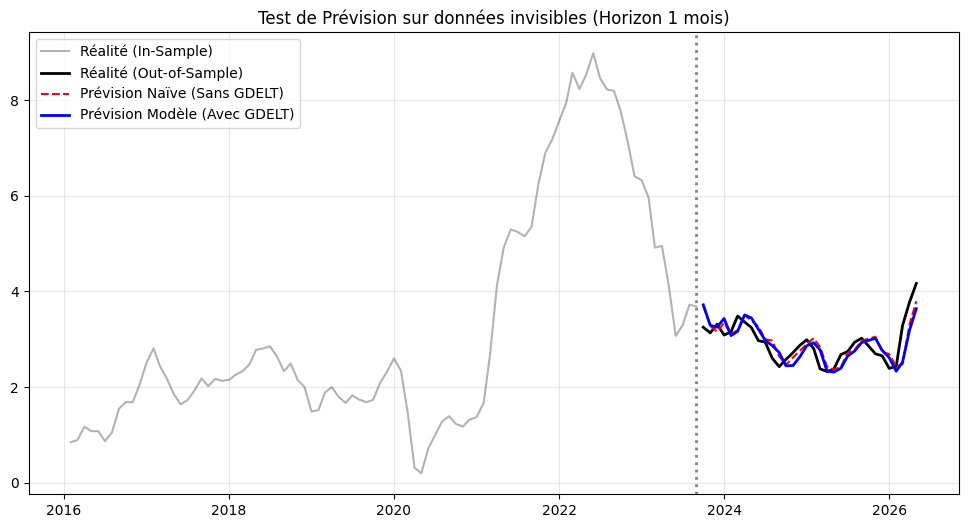


📌 3. DYNAMIQUE DE CHOC (Modèle VAR sur le meilleur prédicteur)
💥 Simulation de Choc (Modèle VAR) sur : att_weight_real_estate_urbanism


/home/clucas/venvs/gdelt/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/clucas/venvs/gdelt/lib/python3.12/site-packages/statsmodels/tsa/vector_ar/irf.py:528: ComplexWarning: Casting complex values to real discards the imaginary part
  W[i,j,:,:], eigva[i,j,:,0], k[i,j] = util.eigval_decomp(cov_hold[i,j,:,:])


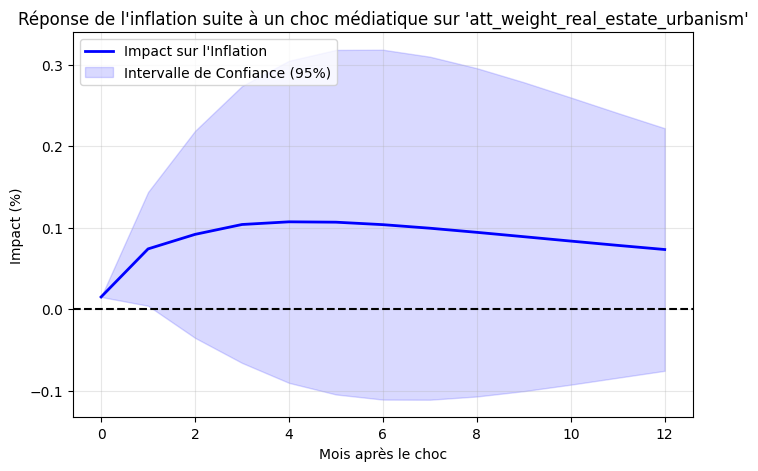

================ FIN DU RAPPORT POUR US ================



In [124]:
# ── COMMENT L'APPELER ──
# compare_regions_predictive_power(df_geo, type_gdelt="att_weight", target_sector="energy", lag_months=2)
# 1. Je veux un audit complet sur l'immobilier aux US
# Un audit complet en 1 ligne (le lag optimal sera découvert tout seul)
generate_regional_report(df_geo, "US", "att_weight", ["real_estate"])

In [116]:
# 2. Je veux savoir quelle zone mondiale est la plus sensible aux récits sur l'énergie
compare_regions_predictive_power(df_geo, "att_weight", "transport", lag_months=3)

🌐 LANCEMENT DU BENCHMARK GLOBAL | Thème : transport | Horizon : T+3


### Test 2 

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
import warnings
warnings.filterwarnings("ignore")

def apply_strict_color_code(val):
    """
    Applique le code couleur : 
    - Foncé (Bleu/Rouge) et texte blanc si *** ou ** (Significatif, p < 0.05)
    - Pâle (Bleu/Rouge) et texte noir si * (Faiblement significatif, p < 0.10)
    - Gris si non significatif (ns) ou 0.00
    """
    val_str = str(val)
    if pd.isna(val) or val == "0.00" or val == "N/A":
        return 'color: #cfd8dc; background-color: #fafafa;'
    
    is_strong = "***" in val_str or "**" in val_str
    is_weak = "*" in val_str and not is_strong
    is_positive = "+" in val_str
    is_negative = "-" in val_str
    
    if is_strong and is_positive:
        return 'background-color: #1565c0; color: white; font-weight: bold;' # Bleu Foncé
    elif is_strong and is_negative:
        return 'background-color: #c62828; color: white; font-weight: bold;' # Rougé Foncé
    elif is_weak and is_positive:
        return 'background-color: #bbdefb; color: black;' # Bleu Pâle
    elif is_weak and is_negative:
        return 'background-color: #ffcdd2; color: black;' # Rouge Pâle
    else:
        return 'color: #78909c; background-color: #eceff1;' # Gris pour (ns)

def run_lasso_horizon(df_model, features, target):
    """Mini-moteur LASSO + OLS pour un horizon donné"""
    X = df_model[features]
    y = df_model[target]
    
    # 1. Sélection LASSO
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    lasso = LassoCV(cv=5, random_state=42, max_iter=10000).fit(X_scaled, y)
    
    # 2. P-values via OLS sur les survivants
    selected = [features[i] for i, coef in enumerate(lasso.coef_) if coef != 0]
    p_values = {f: 1.0 for f in features}
    
    if selected:
        X_ols = sm.add_constant(X[selected])
        ols_model = sm.OLS(y, X_ols).fit()
        for f in selected:
            p_values[f] = ols_model.pvalues[f]
            
    return lasso.coef_, p_values, selected

def format_coef(coef, p_val):
    if coef == 0: return "0.00"
    stars = "***" if p_val < 0.01 else "**" if p_val < 0.05 else "*" if p_val < 0.10 else " (ns)"
    return f"{coef:+.2f}{stars}"

In [20]:
def master_econometric_pipeline(df_align, zscore_cols, macro_col, region_name):
    print("="*80)
    print(f"🚀 PIPELINE ÉCONOMÉTRIQUE GLOBAL : {region_name.upper()}")
    print("="*80)
    
    lag_range = list(range(6, -7, -1)) # De T+6 (Futur) à T-6 (Passé)
    col_names = [(f"T+{l}" if l > 0 else (f"T{l}" if l < 0 else "T(0)")) for l in lag_range]
    
    # =========================================================================
    # ÉTAPE 1 : LE FILTRE GLOBAL (BATTLE ROYALE)
    # =========================================================================
    print("\n" + "▼"*80)
    print("📌 ÉTAPE 1 : FILTRE GLOBAL (COMPÉTITION DE TOUS LES SECTEURS)")
    print("Objectif : Mettre toutes les variables GDELT en concurrence face à l'Inertie Macro.")
    print("Interprétation :")
    print("  - Les cases '0.00' sont les variables éliminées car redondantes (bruit).")
    print("  - Concentrez-vous sur le bloc de gauche (T+6 à T+1) : ce sont les indicateurs AVANCÉS.")
    print("▼"*80)

    row_labels = [c.replace('_zscore', '') for c in zscore_cols] + ["_MACRO_INERTIA_"]
    df_step1 = pd.DataFrame("0.00", index=row_labels, columns=lag_range)
    
    for lag in lag_range:
        X_dict = {col: df_align[col].shift(lag) for col in zscore_cols}
        if lag > 0: # Contrôle autorégressif (AR) stricte pour les prévisions
            X_dict["_MACRO_INERTIA_"] = df_align[macro_col].shift(lag)
            
        df_lag = pd.DataFrame(X_dict, index=df_align.index)
        df_lag[macro_col] = df_align[macro_col]
        df_lag = df_lag.dropna()
        
        if len(df_lag) < 20: continue
            
        features = list(X_dict.keys())
        coefs, p_vals, _ = run_lasso_horizon(df_lag, features, macro_col)
        
        for i, feat in enumerate(features):
            row_name = "_MACRO_INERTIA_" if feat == "_MACRO_INERTIA_" else feat.replace('_zscore', '')
            df_step1.loc[row_name, lag] = format_coef(coefs[i], p_vals[feat])
            
    df_step1.loc["_MACRO_INERTIA_", [l for l in lag_range if l <= 0]] = "N/A"
    df_step1.columns = col_names
    
    display(df_step1.style.map(apply_strict_color_code).set_properties(**{
        'font-size': '12px', 'padding': '6px', 'text-align': 'center', 'border': '1px solid #e0e0e0'
    }))

    # --> DÉTECTION DES SECTEURS PERTINENTS (Ceux qui ont survécu à l'étape 1 dans le futur)
    relevant_sectors = []
    for col in zscore_cols:
        clean_name = col.replace('_zscore', '')
        # On vérifie s'il y a un "***" ou "**" dans les colonnes prédictives (T+1 à T+6)
        has_signal = any(("***" in str(df_step1.loc[clean_name, col_name]) or "**" in str(df_step1.loc[clean_name, col_name])) 
                         for col_name in col_names[:6])
        if has_signal: relevant_sectors.append(col)

    if not relevant_sectors:
        print("\n❌ Aucun secteur ne possède un pouvoir prédictif statistiquement robuste face à l'inertie de l'inflation. Fin de l'analyse.")
        return

    # =========================================================================
    # ÉTAPE 2 : LE FOCUS LOCAL (ISOLATION DU SIGNAL)
    # =========================================================================
    print("\n\n" + "▼"*80)
    print(f"📌 ÉTAPE 2 : FOCUS SUR LES {len(relevant_sectors)} SECTEURS PERTINENTS")
    print("Objectif : Analyser le signal pur de chaque secteur vainqueur (1 LASSO par secteur + AR).")
    print("Interprétation : Les coefficients ici reflètent le vrai pouvoir prédictif isolé.")
    print("▼"*80)

    clean_relevant = [c.replace('_zscore', '') for c in relevant_sectors]
    df_step2 = pd.DataFrame("0.00", index=clean_relevant, columns=lag_range)
    top_candidates = [] # Pour stocker les meilleurs couples (Secteur, Lag) pour l'IRF

    for sector in relevant_sectors:
        clean_name = sector.replace('_zscore', '')
        for lag in lag_range:
            X_dict = {sector: df_align[sector].shift(lag)}
            if lag > 0: X_dict["_MACRO_INERTIA_"] = df_align[macro_col].shift(lag)
                
            df_lag = pd.DataFrame(X_dict, index=df_align.index)
            df_lag[macro_col] = df_align[macro_col]
            df_lag = df_lag.dropna()
            
            if len(df_lag) < 20: continue
                
            features = list(X_dict.keys())
            coefs, p_vals, _ = run_lasso_horizon(df_lag, features, macro_col)
            
            sector_coef = coefs[features.index(sector)]
            sector_pval = p_vals[sector]
            df_step2.loc[clean_name, lag] = format_coef(sector_coef, sector_pval)
            
            # Enregistrement pour l'étape 3 : on cherche le plus gros impact prédictif (lag > 0, p < 0.05)
            if lag > 0 and sector_pval < 0.05 and sector_coef != 0:
                top_candidates.append({'sector': sector, 'lag': lag, 'abs_coef': abs(sector_coef)})

    df_step2.columns = col_names
    display(df_step2.style.map(apply_strict_color_code).set_properties(**{
        'font-size': '12px', 'padding': '6px', 'text-align': 'center', 'border': '1px solid #e0e0e0'
    }))

    if not top_candidates:
        print("\n❌ Bien que pertinents globalement, les secteurs ont perdu leur significativité en isolation. Pas d'IRF possible.")
        return

    # =========================================================================
    # ÉTAPE 3 : DYNAMIQUE DE CHOC (VAR / IRF)
    # =========================================================================
    print("\n\n" + "▼"*80)
    print("📌 ÉTAPE 3 : MODÉLISATION DES CHOCS NARRATIFS (IRF)")
    print("Objectif : Simuler l'impact réel d'une explosion médiatique (+1 écart-type) sur l'économie.")
    print("Variables sélectionnées : Celles ayant les coefficients les plus massifs à l'Etape 2.")
    print("▼"*80)

    # Trier les candidats pour prendre les 2 meilleurs (pour éviter de surcharger l'écran d'IRFs)
    top_candidates = sorted(top_candidates, key=lambda x: x['abs_coef'], reverse=True)
    best_unique_sectors = list(dict.fromkeys([c['sector'] for c in top_candidates]))[:2]

    for best_sector in best_unique_sectors:
        clean_name = best_sector.replace('_zscore', '')
        print(f"\n💥 Génération du choc sur : {clean_name.upper()}")
        
        df_var = df_align[[best_sector, macro_col]].dropna()
        model = VAR(df_var)
        results = model.fit(maxlags=3, ic='aic')
        irf = results.irf(12) # Propagation sur 12 mois
        
        lower_bound_matrix, upper_bound_matrix = irf.err_band_sz1(orth=True, signif=0.05)
        effect_on_macro = irf.orth_irfs[:, 1, 0] 
        lower_bound = lower_bound_matrix[:, 1, 0]
        upper_bound = upper_bound_matrix[:, 1, 0]
        
        plt.figure(figsize=(10, 4))
        plt.plot(range(13), effect_on_macro, color='#1565c0', linewidth=2.5, label=f"Impact sur {macro_col}")
        plt.fill_between(range(13), lower_bound, upper_bound, color='#1565c0', alpha=0.15, label="Intervalle de Confiance (95%)")
        plt.axhline(0, color='black', linestyle='--', linewidth=1)
        
        plt.title(f"Réponse de la macroéconomie à un choc GDELT sur '{clean_name}'", fontsize=12)
        plt.xlabel("Mois suivant le choc")
        plt.ylabel("Impact Standardisé")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

    print("\n" + "="*80)
    print(f"✅ FIN DU PIPELINE POUR {region_name.upper()}")
    print("="*80 + "\n")

Téléchargement FRED pour France (CP0000FRM086NEST)...
📊 Mode Comparaison activé sur 8 secteurs.
🚀 PIPELINE ÉCONOMÉTRIQUE GLOBAL : FRANCE

▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
📌 ÉTAPE 1 : FILTRE GLOBAL (COMPÉTITION DE TOUS LES SECTEURS)
Objectif : Mettre toutes les variables GDELT en concurrence face à l'Inertie Macro.
Interprétation :
  - Les cases '0.00' sont les variables éliminées car redondantes (bruit).
  - Concentrez-vous sur le bloc de gauche (T+6 à T+1) : ce sont les indicateurs AVANCÉS.
▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼


,T+6,T+5,T+4,T+3,T+2,T+1,T(0),T-1,T-2,T-3,T-4,T-5,T-6
att_weight_finance,+0.41***,+0.32***,+0.24***,+0.20***,+0.11**,+0.07**,+0.41***,+0.32***,0.00,0.00,0.00,0.00,0.00
att_weight_energy,+0.15 (ns),+0.14*,+0.09 (ns),+0.06 (ns),+0.08 (ns),+0.00 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_agriculture,+0.46***,+0.44***,+0.36***,+0.25***,+0.13**,+0.05*,+0.00 (ns),0.00,0.00,0.00,0.00,0.00,0.00
att_weight_tech,+0.29***,+0.29***,+0.35***,+0.33***,+0.23***,+0.08***,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_industry,-0.24**,-0.21**,-0.16**,-0.04 (ns),-0.02 (ns),-0.02 (ns),+0.08 (ns),+0.02 (ns),0.00,0.00,0.00,0.00,0.00
att_weight_commodities,-0.01 (ns),-0.04 (ns),-0.11 (ns),-0.10 (ns),-0.05 (ns),0.00,+0.09 (ns),+0.07 (ns),0.00,0.00,0.00,0.00,0.00
att_weight_real_estate,-0.07 (ns),-0.07 (ns),-0.14 (ns),-0.13*,-0.09*,0.00,+0.31**,+0.30**,0.00,0.00,0.00,+0.04***,+0.04***
att_weight_transport,+0.15 (ns),+0.13*,+0.14*,+0.15**,+0.09*,+0.07**,+0.00 (ns),0.00,0.00,0.00,0.00,0.00,0.00
_MACRO_INERTIA_,+1.36***,+1.49***,+1.64***,+1.72***,+1.82***,+1.88***,N/A,N/A,N/A,N/A,N/A,N/A,N/A




▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
📌 ÉTAPE 2 : FOCUS SUR LES 5 SECTEURS PERTINENTS
Objectif : Analyser le signal pur de chaque secteur vainqueur (1 LASSO par secteur + AR).
Interprétation : Les coefficients ici reflètent le vrai pouvoir prédictif isolé.
▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼


,T+6,T+5,T+4,T+3,T+2,T+1,T(0),T-1,T-2,T-3,T-4,T-5,T-6
att_weight_finance,+0.54***,+0.44***,+0.32***,+0.22***,+0.11**,+0.07**,+0.65***,+0.60***,+0.48***,+0.37**,+0.24 (ns),+0.11 (ns),0.00
att_weight_agriculture,+0.51***,+0.48***,+0.35***,+0.26***,+0.14***,+0.07**,+0.45**,+0.36**,+0.25 (ns),+0.16 (ns),0.00,0.00,0.00
att_weight_tech,+0.17*,+0.19**,+0.22***,+0.18***,+0.12***,+0.05**,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_industry,-0.17 (ns),-0.14 (ns),-0.14*,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,+0.03**
att_weight_transport,+0.05 (ns),+0.06 (ns),+0.07 (ns),+0.07 (ns),+0.03 (ns),+0.04*,0.00,0.00,0.00,0.00,0.00,0.00,0.00




▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
📌 ÉTAPE 3 : MODÉLISATION DES CHOCS NARRATIFS (IRF)
Objectif : Simuler l'impact réel d'une explosion médiatique (+1 écart-type) sur l'économie.
Variables sélectionnées : Celles ayant les coefficients les plus massifs à l'Etape 2.
▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼

💥 Génération du choc sur : ATT_WEIGHT_FINANCE


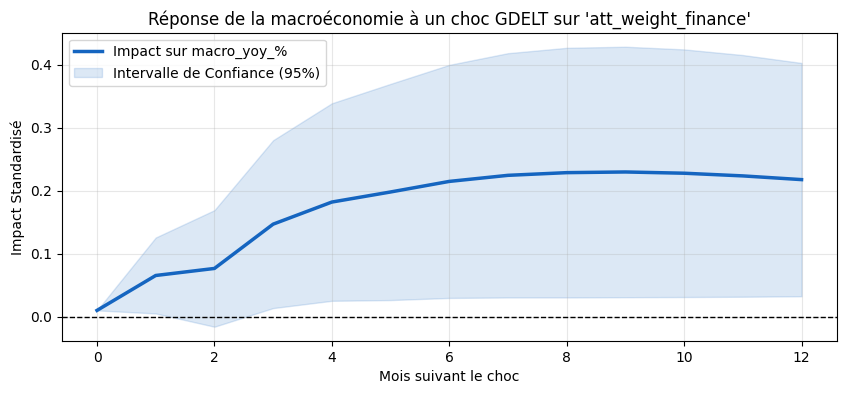


💥 Génération du choc sur : ATT_WEIGHT_AGRICULTURE


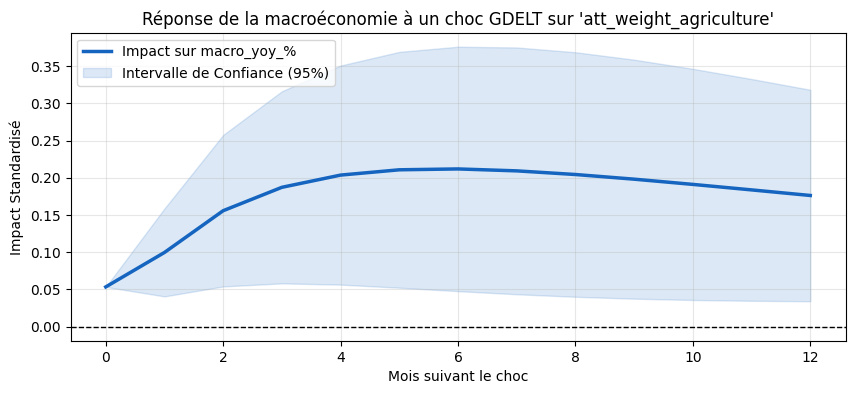


✅ FIN DU PIPELINE POUR FRANCE



In [22]:
# =========================================================================
# ⚙️ 1. PARAMÉTRAGE DE L'ANALYSE
# =========================================================================
region = "France"                         # Pays/Zone à étudier (ex: "France", "European Union")
type_gdelt_indicator = "att_weight"   # L'indicateur GDELT de base (ex: "sent_cont", "att_weight")
sectors = ["finance", "energy", "agriculture", "tech", "industry", "commodities", "real_estate", "transport"]  # Liste des secteurs à comparer

# =========================================================================
# 🔄 2. ALIGNEMENT ET SYNCHRONISATION (Data Prep)
# =========================================================================
# Cette fonction télécharge la macroéconomie (FRED), calcule les Z-Scores GDELT,
# et fusionne le tout sur un calendrier mensuel strict.
df_align, z_cols, m_col = load_and_align_multi(
    df_geo=df_geo, 
    region_key=region, 
    type_gdelt=type_gdelt_indicator, 
    sectors=sectors 
)

# =========================================================================
# 🚀 3. LANCEMENT DU MOTEUR ÉCONOMÉTRIQUE
# =========================================================================
# On envoie les données propres dans le pipeline de modélisation
master_econometric_pipeline(
    df_align=df_align, 
    zscore_cols=z_cols, 
    macro_col=m_col, 
    region_name=region
)